# EDA of the eSEEd_v2 emotion dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import seaborn as sns



## Prepare dataset
- load
- clean

In [ ]:
data_dir = "../../data/processed/eSEEd_v2_processed/"

In [ ]:
# load eseed dataset
def load_eseed_dataset(data_dir):
    strat_time = time.time()
    df = pd.DataFrame()
    for csv_file in os.listdir(data_dir):
        if csv_file.endswith(".csv"):
            df_part = pd.read_csv(os.path.join(data_dir, csv_file))
            df = pd.concat([df, df_part], ignore_index=True)
    print(f"Loaded eSEEd dataset in {time.time() - strat_time:.2f} seconds.")
    return df


In [ ]:
df = load_eseed_dataset(data_dir)
dfOG = df.copy()  # keep original for comparison

In [ ]:
subjects = df['subject'].unique()
recordings = df['recording'].unique()
emotion_cols = [col for col in df.columns if "emotion" in col]

## Percentage of NaN rows 


In [ ]:
# percentage of nan rows (the same for all columns except timestamp, subject, recording)
df = dfOG.copy()
(df.isna().sum() / len(df) * 100)["x-avg"].round(2)

In [ ]:
print("Checking subjects")
for subject in subjects:
    df_subj = df[df['subject'] == subject]
    num_rows = len(df_subj)
    num_nan_rows = df_subj.isna().any(axis=1).sum()
    perc_nan = (num_nan_rows / num_rows) * 100
    if perc_nan > 2:
        print(f"Subject {subject} exceeds {2}% NaN rows: {perc_nan:.2f}% NaN rows ({num_nan_rows}/{num_rows})")

print("\nChecking recordings")
for recording in recordings:
    df_rec = df[df['recording'] == recording]
    num_rows = len(df_rec)
    num_nan_rows = df_rec.isna().any(axis=1).sum()
    perc_nan = (num_nan_rows / num_rows) * 100
    if perc_nan > 1:
        print(f"Recording {recording} exceeds {1}% NaN rows: {perc_nan:.2f}% NaN rows ({num_nan_rows}/{num_rows})")

print("\nChecking emotion columns")
for col in emotion_cols:
    num_rows = len(df)
    num_nan_rows = df[col].isna().sum()
    perc_nan = (num_nan_rows / num_rows) * 100
    print(f"Emotion column {col} exceeds {0}% NaN rows: {perc_nan:.2f}% NaN rows ({num_nan_rows}/{num_rows})")
print("^Same as dataset. Surprise xD")

In [ ]:
# put subject and recording columns first
cols = df.columns.tolist()
cols.insert(0, cols.pop(cols.index("subject")))
cols.insert(1, cols.pop(cols.index("recording")))
df = df[cols]


In [ ]:
df.columns

In [ ]:
# clean df
print(len(df[df["x-avg"] < 0]) / len(df))
print(len(df[df["x-avg"] > 1]) / len(df))
print(len(df[df["y-avg"] < 0]) / len(df))
print(len(df[df["y-avg"] > 1]) / len(df))
df = df[df["x-avg"].isna() | ((df["x-avg"] >= 0) & (df["x-avg"] <= 1) & (df["y-avg"] >= 0) & (df["y-avg"] <= 1))]

print(len(df[df["pupil-size-right-avg"] > 10]) / len(df))
print(len(df[df["pupil-size-left-avg"] > 10]) / len(df))
df = df[df["pupil-size-right-avg"].isna() | ((df["pupil-size-right-avg"] < 10) & (df["pupil-size-left-avg"] < 10))]

## Plot distributions of raw signals per emotion
Signals: x, y, pupil size

In [ ]:
# plot distributions of raw signals per emotion
emotion_cols = [col for col in df.columns if "emotion" in col]
print(emotion_cols)
signals = ["x-avg", "y-avg", "pupil-size-right-avg", "pupil-size-left-avg"]
for signal in signals:
    for tresh in [5]:
        plt.figure(figsize=(5, 2))
        for emotion in emotion_cols:
            data = df.loc[df[emotion] > tresh, signal]
            min_val = data.min()
            max_val = data.max()

            # print(f"Distribution of {signal} for {emotion}:")
            # print(data.describe())
            # print("Percentage of NaN values: ",data.isna().sum()/len(data)*100)
        
            plt.hist(data, bins=100, alpha=0.7, label=emotion)
        plt.title(f"Distribution of {signal}\nMin: {min_val:.2f}, Max: {max_val:.2f}")
        plt.xlabel(signal)
        plt.ylabel("Frequency")
        plt.legend(loc='lower right')
        plt.show()


## Scatter plots: points on screen 
### Colored by emotion

In [ ]:
# scatter plot: each emotion is its own color, size according to intensity, x,y coordinates determined by "x-avg" and "y-avg"
emotion_cols = [col for col in df.columns if "emotion" in col]
# random sample to speed up plotting
df_temp = df.sample(n=5000, random_state=111)
plt.figure(figsize=(5, 5))
for emotion in emotion_cols:
    plt.scatter(df_temp["x-avg"], df_temp["y-avg"], s=df_temp[emotion]*5, alpha=0.33, label=emotion)
plt.title(f"Scatter plot of x-avg vs y-avg colored by emotion intensity")
plt.xlabel("x-avg")
plt.ylabel("y-avg")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()

## Plot average emotion value for pupil size bins for all emotions


In [ ]:
# plot average emotion value for pupil size bins for all emotions
# with shifted centers (side by side)

# Define pupil size bins
pupil_bins = [0, 2, 3, 4, 5, 6, 7, 10]
pupil_labels = ['<2mm', '2-3mm', '3-4mm', '4-5mm', '5-6mm', '6-7mm', '>7mm']

emotion_cols = [col for col in df.columns if "emotion" in col]

plt.figure(figsize=(7, 3))

bar_width = 0.8 / len(emotion_cols)  # Width of each emotion's bars
x_positions = np.arange(len(pupil_labels))

for idx, emotion in enumerate(emotion_cols):
    # Create a copy of the data with non-null values
    df_temp = df[['pupil-size-left-avg', emotion]].dropna()
    
    # Create bins
    df_temp['pupil_bin'] = pd.cut(df_temp['pupil-size-left-avg'], bins=pupil_bins, labels=pupil_labels, include_lowest=True)
    
    # Calculate average emotion for each bin
    avg_emotion_per_bin = df_temp.groupby('pupil_bin',observed=False)[emotion].mean()
    count_per_bin = df_temp.groupby('pupil_bin',observed=False).size()
    
    print(f"\n{emotion}:")
    # print(f"Average per bin: {avg_emotion_per_bin.values}")
    print(f"Count per bin: {count_per_bin.values}")
    
    # Shift bin centers for each emotion
    shifted_positions = x_positions + (idx - len(emotion_cols)/2 + 0.5) * bar_width
    
    # Plot bars
    plt.bar(shifted_positions, avg_emotion_per_bin.values, width=bar_width, alpha=0.7, label=emotion)

plt.xticks(x_positions, pupil_labels)
plt.xlabel('Pupil Size Left (bins)')
plt.ylabel('Average Emotion Intensity')
plt.title('Average Emotion Intensity by Pupil Size (Left) Bins')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


## Plot average pupil size for each emotion intensity value


In [ ]:
# plot average pupil size for each emotion intensity value
# emotion values are discrete 0-10, plot average pupil size for each emotion value

emotion_cols = [col for col in df.columns if "emotion" in col]

plt.figure(figsize=(7, 3))

bar_width = 0.8 / len(emotion_cols)  # Width of each emotion's bars
emotion_values = np.arange(0, 11)  # 0 to 10

for idx, emotion in enumerate(emotion_cols):
    # Create a copy of the data with non-null values
    df_temp = df[['pupil-size-left-avg', emotion]].dropna()
    
    # Round emotion values to integers (in case they're floats)
    df_temp[emotion] = df_temp[emotion].round().astype(int)
    
    # Calculate average pupil size for each emotion value
    avg_pupil_per_emotion = df_temp.groupby(emotion)['pupil-size-left-avg'].mean()
    count_per_emotion = df_temp.groupby(emotion).size()
    
    print(f"\n{emotion}:")
    print(f"Count per emotion value: {count_per_emotion.values}")
    
    # Reindex to include all emotion values 0-10, fill missing with NaN
    avg_pupil_per_emotion = avg_pupil_per_emotion.reindex(emotion_values)
    
    # Shift bin centers for each emotion
    shifted_positions = emotion_values + (idx - len(emotion_cols)/2 + 0.5) * bar_width
    
    # Plot bars (only where we have data)
    plt.bar(shifted_positions, avg_pupil_per_emotion.values, width=bar_width, alpha=0.7, label=emotion)

plt.xticks(emotion_values)
plt.xlabel('Emotion Intensity Value')
plt.ylabel('Average Pupil Size Left (mm)')
plt.title('Average Pupil Size (Left) by Emotion Intensity Value')
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.show()


## Emotion distributions

In [ ]:
# =========================================================================
# plot emotion distributions
# =========================================================================
exclude_zero = 0

emotion_cols = [col for col in df.columns if "emotion" in col]
plt.figure(figsize=(7, 3))
# Define discrete bins for emotion values (1-10)
bins = np.arange(-0.5+exclude_zero, 11.5, 1)  # Creates bins centered at 1, 2, ..., 10
bar_width = 0.8 / len(emotion_cols)  # Width of each emotion's bars

for idx, emotion in enumerate(emotion_cols):
    data = df[emotion].dropna()
    min_val = data.min()
    max_val = data.max()
    
    # Calculate histogram
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # Shift bin centers for each emotion
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    shifted_centers = bin_centers + (idx - len(emotion_cols)/2 + 0.5) * bar_width
    
    # Plot as bar chart
    plt.bar(shifted_centers, counts, width=bar_width, alpha=0.7, label=emotion)
    
    # print(f"{emotion}: Min={min_val:.2f}, Max={max_val:.2f}, Count={len(data)}")

plt.title(f"Distribution of Emotion Intensities (Side by Side)")
plt.xlabel("Emotion Intensity")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.xticks(range(0+exclude_zero, 11))
plt.show()

# =========================================================================
# count each (subject, recording) pair once
# =========================================================================


# keep exactly one row per (subject, recording) so each pair is counted once
df_sr = df.dropna().drop_duplicates(subset=["subject", "recording"])[["subject", "recording"] + emotion_cols]

plt.figure(figsize=(7, 3))
bins = np.arange(-0.5 + exclude_zero, 11.5, 1)  # bins centered at 1..10 (or 0..10 if exclude_zero=0)
bar_width = 0.8 / len(emotion_cols)

for idx, emotion in enumerate(emotion_cols):
    data = df_sr[emotion].dropna()
    min_val, max_val = data.min(), data.max()

    counts, bin_edges = np.histogram(data, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    shifted_centers = bin_centers + (idx - len(emotion_cols)/2 + 0.5) * bar_width

    plt.bar(shifted_centers, counts, width=bar_width, alpha=0.7, label=emotion)
    # print(f"{emotion}: Min={min_val:.2f}, Max={max_val:.2f}, Count={len(data)}")

plt.title("Distribution of Emotion Intensities (counting each subject-recording once)")
plt.xlabel("Emotion Intensity")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.xticks(range(0 + exclude_zero, 11))
plt.show()

### Emotion distr. for each subject separately
Warning: 48 plots.

In [ ]:
run_this_cell = False

if run_this_cell:
    # plot emotion distributions for each subject
    exclude_zero = 0

    emotion_cols = [col for col in df.columns if "emotion" in col]
    subjects = df['subject'].unique()

    for subject in subjects:
        plt.figure(figsize=(7, 4))
        
        # keep exactly one row per (subject, recording) so each pair is counted once
        df_temp = df[df['subject'] == subject]
        df_sr = df_temp.dropna().drop_duplicates(subset=["recording"])[["recording"] + emotion_cols]

        bins = np.arange(-0.5 + exclude_zero, 11.5, 1)  # bins centered at 1..10 (or 0..10 if exclude_zero=0)
        bar_width = 0.8 / len(emotion_cols)

        for idx, emotion in enumerate(emotion_cols):
            data = df_sr[emotion].dropna()
            min_val, max_val = data.min(), data.max()

            counts, bin_edges = np.histogram(data, bins=bins)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            shifted_centers = bin_centers + (idx - len(emotion_cols)/2 + 0.5) * bar_width

            plt.bar(shifted_centers, counts, width=bar_width, alpha=0.7, label=emotion)
            # print(f"{emotion}: Min={min_val:.2f}, Max={max_val:.2f}, Count={len(data)}")

        plt.title("Distribution of Emotion Intensities (counting each subject-recording once)")
        plt.xlabel("Emotion Intensity")
        plt.ylabel("Frequency")
        plt.grid(axis="y", alpha=0.3)
        plt.legend()
        plt.xticks(range(0 + exclude_zero, 11))
        plt.show()

### Average emotion intensity by recording

In [ ]:
# keep exactly one row per (subject, recording) so each pair is counted once
df_sr = df.dropna().drop_duplicates(subset=["subject", "recording"])[["subject", "recording"] + emotion_cols]

# calculate average emotion intensity per recording
recordings = df_sr["recording"].unique()
recordings.sort()
avg_intensity_per_recording = {}

for emotion in emotion_cols:
    avg_intensity_per_recording[emotion] = df_sr.groupby("recording")[emotion].mean()

# plot
plt.figure(figsize=(10, 4))
bar_width = 0.8 / len(emotion_cols)
x_positions = np.arange(len(recordings))

for idx, emotion in enumerate(emotion_cols):
    avg_values = [avg_intensity_per_recording[emotion].get(rec, 0) for rec in recordings]
    shifted_positions = x_positions + (idx - len(emotion_cols)/2 + 0.5) * bar_width
    plt.bar(shifted_positions, avg_values, width=bar_width, alpha=0.7, label=emotion)

plt.xticks(x_positions, recordings, ha='right')
plt.xlabel("Recording")
plt.ylabel("Average Emotion Intensity")
plt.title("Average Emotion Intensity by Recording")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Intended emotions by recording
| Index | Movie | Duration | Emotion |
|---- | ----| ----| ----|   
|1 | American history X | 1.17 | Anger| 
|2 | Benny and Joon | 2.01 | Tenderness| 
|3 | Blue (2) | 0.40 | Neutral| 
|4 | Ghost | 1.19 | Tenderness| 
|5 | Man bites dog (1) | 1.32 | Disgust| 
|6 | Schindler’s list (1) | 0.58 | Sadness| 
|7 | Schindler’s list (2) | 1.55 | Anger| 
|8 | The dreamlife of angels | 2.00 | Sadness| 
|9 | The lover | 0.43 | Neutral| 
|10 | Trainspotting (2) | 1.00 | Disgust| 

### Number of Subjects by Unique Emotion Intensities Reported 

In [ ]:

emotion_cols = [c for c in df.columns if "emotion" in c]
emo_plus_any = emotion_cols + ["any"]

subjects = df["subject"].unique()
max_unique_intensities = 10  # intensities 1..10
unique_intensity_counts = {e: np.zeros(max_unique_intensities, dtype=int) for e in emo_plus_any}

for subject in subjects:
    df_temp = df[df["subject"] == subject]

    # one row per recording for this subject (emotion constant per subject-recording)
    df_sr = df_temp.dropna(subset=["recording"]).drop_duplicates(subset=["recording"])[["recording"] + emotion_cols]

    # "any": total number of unique emotion values across all emotion columns & recordings for this subject
    # (values in 1..10; NaNs ignored)
    any_vals = pd.unique(df_sr[emotion_cols].to_numpy().ravel())
    any_vals = any_vals[~pd.isna(any_vals)]
    num_unique_any = len(any_vals)
    for i in range(min(num_unique_any, max_unique_intensities)):
        unique_intensity_counts["any"][i] += 1

    # per-emotion
    for emotion in emotion_cols:
        unique_intensities = df_sr[emotion].dropna().unique()
        num_unique = len(unique_intensities)
        for i in range(min(num_unique, max_unique_intensities)):
            unique_intensity_counts[emotion][i] += 1

# plot
plt.figure(figsize=(7, 3))
bar_width = 0.8 / len(emo_plus_any)
x_positions = np.arange(max_unique_intensities) + 1  # 1..10

for idx, emotion in enumerate(emo_plus_any):
    counts = unique_intensity_counts[emotion]
    shifted_positions = x_positions + (idx - len(emo_plus_any)/2 + 0.5) * bar_width
    plt.bar(shifted_positions, counts, width=bar_width, alpha=0.7, label=emotion)

plt.xticks(x_positions)
plt.xlabel("Number of Unique Emotion Intensities Reported")
plt.ylabel("Number of Subjects")
plt.title("Number of Subjects by Unique Emotion Intensities Reported per Emotion Category (+ any)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

## Number of subject-recording pairs with all emotions reported as <= `thresh`

In [ ]:
# how many subject, recording pairs have all emotions reported as <= thresh
# keep exactly one row per (subject, recording) so each pair is counted once
df_sr = df.dropna().drop_duplicates(subset=["subject", "recording"])[["subject", "recording"] + emotion_cols]

# check if all emotions are <= thresh for each (subject, recording) pair
thresh = 1
all_zero = (df_sr[emotion_cols] <= thresh).all(axis=1)

num_all_zero = all_zero.sum()
print(f"Number of subject-recording pairs with all emotions reported <= {thresh}: {num_all_zero}")
print(f"Subject-recording pairs with all emotions reported <= {thresh}:")
print(df_sr.loc[all_zero, ["subject", "recording"]])

`df_sr` is subject-recording aggregated df

In [ ]:
df = dfOG.copy() 
df_sr = df.dropna().groupby(["subject", "recording"]).mean(numeric_only=True).reset_index()


In [ ]:
neutral_combinations = (df_sr[emotion_cols] == 0).all(axis=1).sum()
print(f"Number of netural subj-rec combinations: {neutral_combinations}. All combinations: {len(df_sr)}")

## Outliers based on z-score of averages
### Outliers - Subject-recording paris 
- if score_l2 ~ score_max => then one metric dominates the outlier score, others are not contributing much

In [ ]:
def robust_z(x):
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    if mad == 0 or np.isnan(mad):
        return (x - med) * 0.0
    return 0.6745 * (x - med) / mad  # consistent w/ std for normal

def compute_outliers(df, cols):
    Z = df[cols].apply(robust_z, axis=0)
    df['outlier_score_l2'] = np.sqrt((Z**2).sum(axis=1))
    df['outlier_score_max'] = Z.abs().max(axis=1)

    # flag top outliers
    df = df.sort_values('outlier_score_l2', ascending=False)

    return df


In [ ]:
# outliers based on signals 
signal_cols = ['x-avg', 'y-avg', 'pupil-size-left-avg', 'pupil-size-right-avg']
df_sr = compute_outliers(df_sr, signal_cols)

plt.figure(figsize=(7, 4))
sns.heatmap(df_sr.pivot(index='subject', columns='recording', values='outlier_score_l2'), cmap='mako')
plt.title('Heatmap of Signal Outlier Scores (L2) per Subject-Recording')
plt.xlabel('Recording')
plt.ylabel('Subject')
plt.show()

df_sr[['subject','recording','outlier_score_l2','outlier_score_max'] + signal_cols].head(6)

In [ ]:
# outliers based on emotions 
df_sr = compute_outliers(df_sr, emotion_cols)
plt.figure(figsize=(7, 4))
sns.heatmap(df_sr.pivot(index='subject', columns='recording', values='outlier_score_l2'), cmap='mako')
plt.title('Heatmap of Emotion Outlier Scores (L2) per Subject-Recording')
plt.xlabel('Recording')
plt.ylabel('Subject')
plt.show()

df_sr[['subject','recording','outlier_score_l2','outlier_score_max'] + emotion_cols].head(6)

### Outliers - Subjects

In [ ]:
df_s = df.groupby("subject").mean(numeric_only=True).reset_index()
df_s = compute_outliers(df_s, signal_cols)
df_s[['subject','outlier_score_l2','outlier_score_max'] + signal_cols].head(6)

In [ ]:
df_s = df.groupby("subject").mean(numeric_only=True).reset_index()
df_s = compute_outliers(df_s, emotion_cols)
df_s[['subject','outlier_score_l2','outlier_score_max'] + emotion_cols].head(6)

### Outliers - Recordings

In [ ]:
df_s = df.groupby("recording").mean(numeric_only=True).reset_index()
df_s = compute_outliers(df_s, signal_cols)
df_s[['recording','outlier_score_l2','outlier_score_max'] + signal_cols].head(6)

In [ ]:
df_s = df.groupby("recording").mean(numeric_only=True).reset_index()
df_s = compute_outliers(df_s, emotion_cols)
df_s[['recording','outlier_score_l2','outlier_score_max'] + emotion_cols].head(6)

## Statistical Analysis: Left vs Right Pupil Size Differences by Subject

In [ ]:
# Statistical analysis of left vs right pupil size per subject
df_pupils = df[['subject', 'pupil-size-left-avg', 'pupil-size-right-avg']].dropna()

stats_per_subject = []
for subject in df_pupils['subject'].unique():
    left = df_pupils.loc[df_pupils['subject'] == subject, 'pupil-size-left-avg']
    right = df_pupils.loc[df_pupils['subject'] == subject, 'pupil-size-right-avg']
    
    stats_per_subject.append({
        'subject': subject,
        'n_samples': len(left),
        'corr': left.corr(right),
        'mae': np.abs(left - right).mean(),
        'rmse': np.sqrt(((left - right) ** 2).mean()),
        'max_diff': np.abs(left - right).max(),
        'mean_left': left.mean(),
        'mean_right': right.mean()
    })

df_stats = pd.DataFrame(stats_per_subject).sort_values('mae', ascending=False)
print("Pupil Size Comparison Statistics per Subject (sorted by MAE):\n")
print(df_stats.to_string(index=False))
print(f"\n\nOverall Statistics Across All Subjects:")
print(f"  Median MAE: {df_stats['mae'].median():.3f} mm")
print(f"  Median Correlation: {df_stats['corr'].median():.3f}")
print(f"  Subjects with MAE > 0.5 mm: {(df_stats['mae'] > 0.5).sum()}")
print(f"  Subjects with correlation < 0.9: {(df_stats['corr'] < 0.9).sum()}")

In [ ]:
# Plot left vs right pupil sizes for critical subjects (top 6 by MAE)
critical_subjects = df_stats.head(6)['subject'].values
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, subject in enumerate(critical_subjects):
    df_subj = df_pupils[df_pupils['subject'] == subject].reset_index(drop=True)
    left = df_subj['pupil-size-left-avg']
    right = df_subj['pupil-size-right-avg']
    
    ax = axes[idx]
    ax.plot(left.values, label='Left', alpha=0.7, linewidth=1, color='#2E86AB')
    ax.plot(right.values, label='Right', alpha=0.7, linewidth=1, color='#A23B72')
    
    # Add statistics
    stats = df_stats[df_stats['subject'] == subject].iloc[0]
    ax.set_title(f"Subject {subject}\nMAE={stats['mae']:.3f}mm, Corr={stats['corr']:.3f}", fontsize=10)
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Pupil Size (mm)')
    ax.legend(loc='best')
    ax.grid(alpha=0.3)

plt.suptitle('Left vs Right Pupil Size for Critical Subjects (Highest MAE)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Scatter plot: left vs right pupil size for each critical subject separately
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, subject in enumerate(critical_subjects):
    df_subj = df_pupils[df_pupils['subject'] == subject].reset_index(drop=True)
    left = df_subj['pupil-size-left-avg']
    right = df_subj['pupil-size-right-avg']
    
    ax = axes[idx]
    ax.scatter(left, right, alpha=0.5, s=20, color='steelblue', edgecolors='black', linewidth=0.5)
    
    # Add perfect agreement line
    min_val = min(left.min(), right.min())
    max_val = max(left.max(), right.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Agreement')
    
    # Add statistics
    stats = df_stats[df_stats['subject'] == subject].iloc[0]
    ax.set_title(f"Subject {subject}\nMAE={stats['mae']:.3f}mm, Corr={stats['corr']:.3f}, N={len(left)}", 
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Left Pupil Size (mm)')
    ax.set_ylabel('Right Pupil Size (mm)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)
    ax.axis('equal')
    
    # Set equal limits
    ax.set_xlim(min_val - 0.5, max_val + 0.5)
    ax.set_ylim(min_val - 0.5, max_val + 0.5)

plt.suptitle('Left vs Right Pupil Size: Individual Scatter Plots for Critical Subjects', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Scatter plot: left vs right pupil size for each critical subject separately
uncritical_subjects = df_stats.tail(6)['subject'].values
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, subject in enumerate(uncritical_subjects):
    df_subj = df_pupils[df_pupils['subject'] == subject].reset_index(drop=True)
    left = df_subj['pupil-size-left-avg']
    right = df_subj['pupil-size-right-avg']
    
    ax = axes[idx]
    ax.scatter(left, right, alpha=0.5, s=20, color='steelblue', edgecolors='black', linewidth=0.5)
    
    # Add perfect agreement line
    min_val = min(left.min(), right.min())
    max_val = max(left.max(), right.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Agreement')
    
    # Add statistics
    stats = df_stats[df_stats['subject'] == subject].iloc[0]
    ax.set_title(f"Subject {subject}\nMAE={stats['mae']:.3f}mm, Corr={stats['corr']:.3f}, N={len(left)}", 
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Left Pupil Size (mm)')
    ax.set_ylabel('Right Pupil Size (mm)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)
    ax.axis('equal')
    
    # Set equal limits
    ax.set_xlim(min_val - 0.5, max_val + 0.5)
    ax.set_ylim(min_val - 0.5, max_val + 0.5)

plt.suptitle('Left vs Right Pupil Size: Individual Scatter Plots for Uncritical Subjects', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Percentage of Outlier Points within Each Subject

In [ ]:
# Calculate percentage of outlier points within each subject
# Define outliers as points where |left - right| exceeds a threshold based on robust statistics

outlier_results = []

for subject in df_pupils['subject'].unique():
    df_subj = df_pupils[df_pupils['subject'] == subject]
    left = df_subj['pupil-size-left-avg']
    right = df_subj['pupil-size-right-avg']
    
    # Calculate differences
    diff = np.abs(left - right)
    
    # Robust outlier detection: MAD-based threshold
    median_diff = np.median(diff)
    mad = np.median(np.abs(diff - median_diff))
    
    # Outliers: points > median + 3*MAD (robust version of 3-sigma rule)
    threshold = median_diff + 3 * 1.4826 * mad  # 1.4826 makes MAD consistent with std for normal dist
    outliers = diff > threshold
    n_outliers = outliers.sum()
    pct_outliers = (n_outliers / len(diff)) * 100
    
    outlier_results.append({
        'subject': subject,
        'n_points': len(diff),
        'n_outliers': n_outliers,
        'pct_outliers': pct_outliers,
        'median_diff': median_diff,
        'mad': mad,
        'threshold': threshold,
        'max_diff': diff.max()
    })

df_outliers = pd.DataFrame(outlier_results).sort_values('pct_outliers', ascending=False)

print("Outlier Analysis per Subject (sorted by % outliers):\n")
print(df_outliers.to_string(index=False))
print(f"\n\nSummary Statistics:")
print(f"  Median % outliers across subjects: {df_outliers['pct_outliers'].median():.2f}%")
print(f"  Subjects with >10% outliers: {(df_outliers['pct_outliers'] > 10).sum()}")
print(f"  Subjects with >5% outliers: {(df_outliers['pct_outliers'] > 5).sum()}")

In [ ]:
# Visualize outlier percentages for critical subjects
fig, ax = plt.subplots(figsize=(10, 5))

# Highlight critical subjects
colors = ['#E63946' if subj in critical_subjects else '#457B9D' 
          for subj in df_outliers['subject']]

bars = ax.bar(range(len(df_outliers)), df_outliers['pct_outliers'], color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Subject', fontweight='bold')
ax.set_ylabel('% Outlier Points', fontweight='bold')
ax.set_title('Percentage of Outlier Points per Subject\n(Red = Critical Subjects)', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(df_outliers)))
ax.set_xticklabels(df_outliers['subject'], rotation=90, fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=5, color='orange', linestyle='--', linewidth=1.5, label='5% threshold')
ax.axhline(y=10, color='red', linestyle='--', linewidth=1.5, label='10% threshold')
ax.legend()

plt.tight_layout()
plt.show()

# Print detailed info for critical subjects
print("\n\nDetailed Outlier Analysis for Critical Subjects:")
print("=" * 80)
for subject in critical_subjects:
    info = df_outliers[df_outliers['subject'] == subject].iloc[0]
    print(f"\nSubject {subject}:")
    print(f"  Total points: {info['n_points']}")
    print(f"  Outlier points: {info['n_outliers']} ({info['pct_outliers']:.2f}%)")
    print(f"  Median |left-right| difference: {info['median_diff']:.3f} mm")
    print(f"  MAD: {info['mad']:.3f} mm")
    print(f"  Outlier threshold: {info['threshold']:.3f} mm")
    print(f"  Max difference: {info['max_diff']:.3f} mm")

### Analyse "nice" subjects

label distribution for nice subjects - histograms of emotion values for each subject-emotion pair separately

Subject 12:
  emotion-anger: Min=0.00, Max=1.00, Count=10


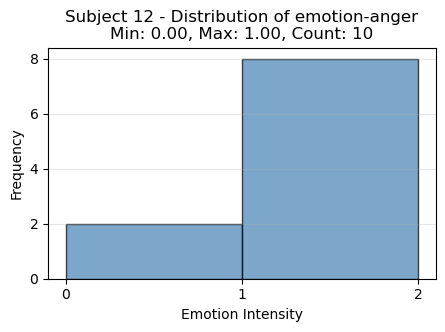


Subject 21:
  emotion-anger: Min=0.00, Max=1.00, Count=10


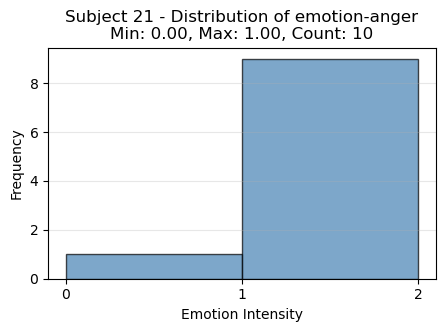


Subject 26:
  emotion-anger: Min=0.00, Max=1.00, Count=10


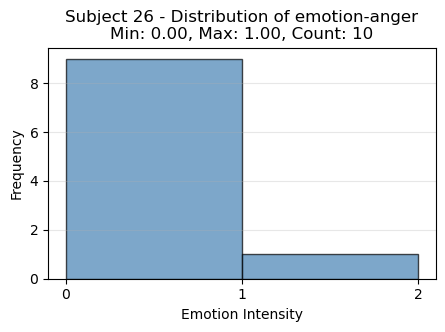


Subject 29:
  emotion-anger: Min=0.00, Max=1.00, Count=10


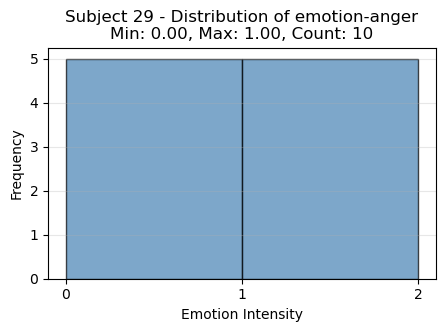


Subject 32:
  emotion-anger: Min=1.00, Max=1.00, Count=10


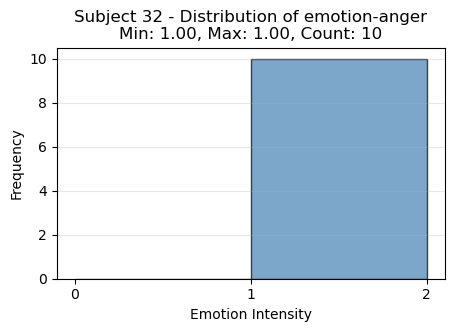


Subject 45:
  emotion-anger: Min=0.00, Max=1.00, Count=10


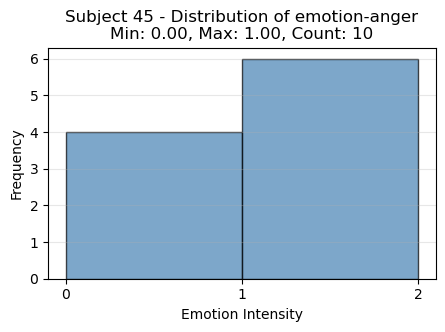

In [43]:
nice_subjects = [12, 21, 26, 29, 32, 45]
picked_emotion = "emotion-anger"
binary = True # 0 vs 1+ intensities

dftemp = df[df['subject'].isin(nice_subjects)]
dftemp = dftemp[[picked_emotion, 'subject', 'recording', 'x-avg', 'y-avg', 'pupil-size-left-avg', 'pupil-size-right-avg']].dropna()

print("label distribution for nice subjects - histograms of emotion values for each subject-emotion pair separately")
for subject in nice_subjects:
    df_subj = dftemp[dftemp['subject'] == subject]
    df_sr_subj = df_subj.dropna().drop_duplicates(subset=["recording"])[["recording"] + [picked_emotion]]
    print(f"\nSubject {subject}:")
    for emotion in [picked_emotion]:
        data = df_sr_subj[emotion].dropna()
        if binary:
            data = (data > 0).astype(int)
        min_val = data.min()
        max_val = data.max()
        count = len(data)
        print(f"  {emotion}: Min={min_val:.2f}, Max={max_val:.2f}, Count={count}")
        
        plt.figure(figsize=(5, 3))
        plt.hist(data, bins=range(0, 3), alpha=0.7, color='steelblue', edgecolor='black')
        plt.title(f"Subject {subject} - Distribution of {emotion}\nMin: {min_val:.2f}, Max: {max_val:.2f}, Count: {count}")
        plt.xlabel("Emotion Intensity")
        plt.ylabel("Frequency")
        plt.xticks(range(0, 3))
        plt.grid(axis='y', alpha=0.3)
        plt.show()




pupil size distribution for nice subjects - histogram


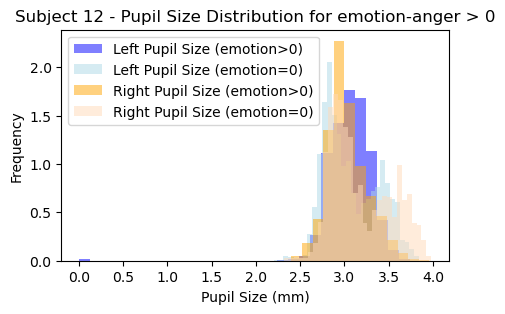

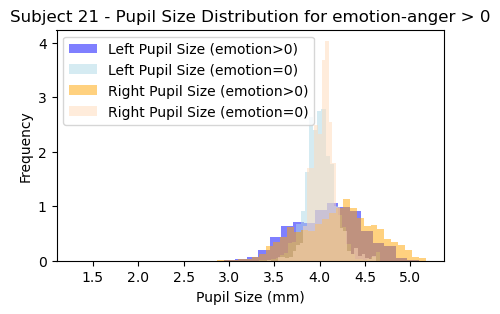

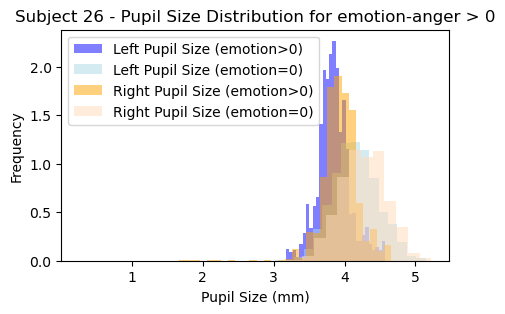

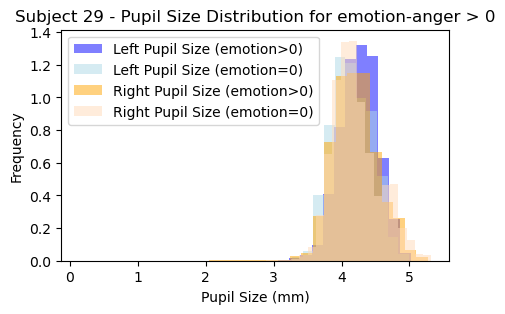

/home/ppg/miniconda3/envs/gfm/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


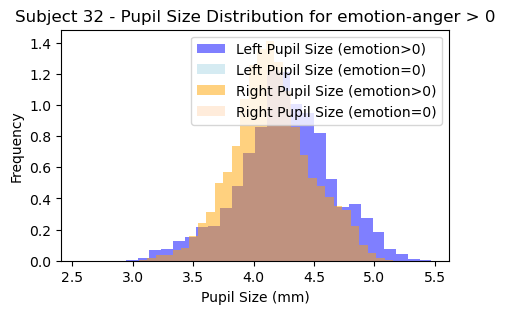

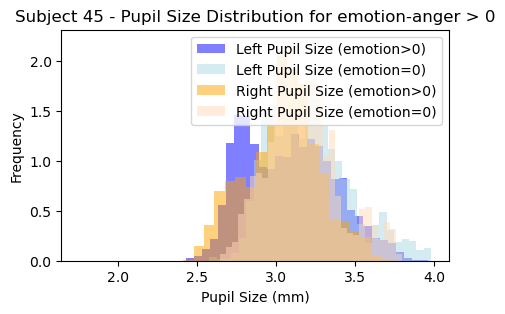

In [49]:

print("pupil size distribution for nice subjects - histogram")
for subject in nice_subjects:
    df_subj = dftemp[dftemp['subject'] == subject]
    df_sr_subj = df_subj.dropna()[["recording"] + [picked_emotion] + ['pupil-size-left-avg', 'pupil-size-right-avg']]
    
    for emotion in [picked_emotion]:
            plt.figure(figsize=(5, 3))
            data_left_pos = df_sr_subj.loc[df_sr_subj[emotion] > 0, 'pupil-size-left-avg']
            data_right_pos = df_sr_subj.loc[df_sr_subj[emotion] > 0, 'pupil-size-right-avg']
            
            data_left_neg = df_sr_subj.loc[df_sr_subj[emotion] == 0, 'pupil-size-left-avg']
            data_right_neg = df_sr_subj.loc[df_sr_subj[emotion] == 0, 'pupil-size-right-avg']
            plt.hist(data_left_pos, bins=30, alpha=0.5, label='Left Pupil Size (emotion>0)', color='blue', density=True, weights=np.ones(len(data_left_pos)) / len(df_sr_subj) * 100)
            plt.hist(data_left_neg, bins=30, alpha=0.5, label='Left Pupil Size (emotion=0)', color='lightblue', density=True, weights=np.ones(len(data_left_neg)) / len(df_sr_subj) * 100)
            plt.hist(data_right_pos, bins=30, alpha=0.5, label='Right Pupil Size (emotion>0)', color='orange', density=True, weights=np.ones(len(data_right_pos)) / len(df_sr_subj) * 100)
            plt.hist(data_right_neg, bins=30, alpha=0.5, label='Right Pupil Size (emotion=0)', color='peachpuff', density=True, weights=np.ones(len(data_right_neg)) / len(df_sr_subj) * 100)
            
            plt.title(f"Subject {subject} - Pupil Size Distribution for {emotion} > 0")
            plt.xlabel("Pupil Size (mm)")
            plt.ylabel("Frequency")
            plt.legend()
            plt.show()
